# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-4: Creación y medición del estado de Bell (Cirq)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-4.

El estado de Bell $|\Phi^+\rangle$ es uno de los cuatro estados de Bell maximalmente entrelazados:

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

Se construye aplicando Hadamard al qubit A (control) y luego CNOT con B (objetivo):

$$|00\rangle \xrightarrow{H \otimes I} \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)|0\rangle \xrightarrow{\text{CNOT}} \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

Al medir, solo podemos obtener |00⟩ o |11⟩ con probabilidad ~0.5 cada uno — nunca |01⟩ ni |10⟩.

### Definición del circuito

> **Nota:** el libro usa `cirq.LineQubit` (cadena lineal de qubits) en lugar de `cirq.GridQubit`.
> También aparece el nombre `cirquit` en el original — probable errata tipográfica; aquí se usa `circuit`.

In [1]:
import cirq

q_register = [cirq.LineQubit(i) for i in range(2)]

circuit = cirq.Circuit([
    cirq.H(q_register[0]),
    cirq.CNOT(q_register[0], q_register[1]),
])
circuit.append(cirq.measure(*q_register, key='z'))

print(circuit)

0: ───H───@───M('z')───
          │   │
1: ───────X───M────────


### Visualización del circuito

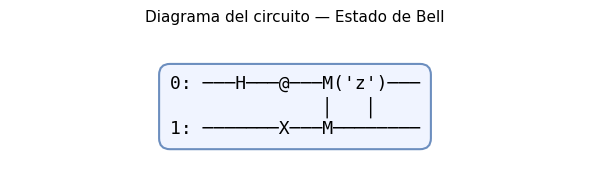

In [2]:
import matplotlib.pyplot as plt

diagrama = circuit.to_text_diagram()

fig, ax = plt.subplots(figsize=(6, 2))
ax.text(
    0.5, 0.5, diagrama,
    fontfamily='monospace', fontsize=13,
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f0f4ff', edgecolor='#6c8ebf', linewidth=1.5),
)
ax.axis('off')
ax.set_title('Diagrama del circuito — Estado de Bell', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

### Simulación

In [3]:
sim = cirq.Simulator()
output = sim.run(circuit, repetitions=100)

print("Salida de medición (enteros):")
print(output.histogram(key='z'))

Salida de medición (enteros):
Counter({3: 51, 0: 49})


### Histograma de mediciones

Cirq codifica el resultado de 2 qubits como un entero: 0 → |00⟩, 3 → |11⟩ (representación binaria little-endian).
Convertimos las claves a binario para que el histograma sea legible.

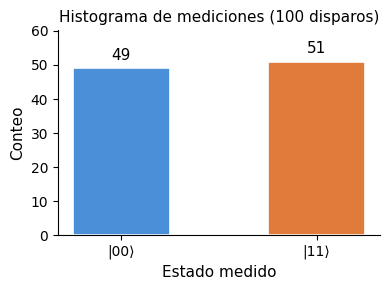

In [4]:
from qml_santanu.common.plot_utils import plot_counts

conteos_binario = {
    format(k, '02b'): v
    for k, v in output.histogram(key='z').items()
}
plot_counts(conteos_binario)